# 🎌 Anime Recommender — EDA and Weighted Cosine Similarity

### A Recommendation System Project by Yonathan Hary Hutagalung @Github/YonathanHH

Dataset credit: [Crunchyroll Anime Recommender — EDA, TF-IDF, SHAP by Mehvish Sheikh on Kaggle](https://www.kaggle.com/code/mehvishsheikh31/crunchyroll-anime-recommender-eda-tf-idf-shap)

## 1. Setup and data loading

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.metrics.pairwise import cosine_similarity

plt.style.use('dark_background')

In [33]:
df = pd.read_csv('animes.csv')
GENRE_COLS = [c for c in df.columns if c.startswith('genre_')]
GENRE_LABELS = [c.replace('genre_', '').replace('-', ' ').title() for c in GENRE_COLS]

df.head()

,anime,anime_url,anime_img,episodes,votes,weight,rate,rate_1,rate_2,rate_3,...,genre_romance,genre_sci-fi,genre_seinen,genre_sgdrama,genre_shojo,genre_shonen,genre_slice of life,genre_sports,genre_supernatural,genre_thriller
0,Naruto Shippuuden,https://www.crunchyroll.com/naruto-shippuden,https://img1.ak.crunchyroll.com/i/spire4/1c1df...,500,48518,233346,4.81,1111,275,817,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Shugo Chara,https://www.crunchyroll.com/shugo-chara,https://img1.ak.crunchyroll.com/i/spire1/7c0c0...,51,33688,163641,4.86,503,104,438,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,BLEACH,https://www.crunchyroll.com/bleach,https://img1.ak.crunchyroll.com/i/spire2/52edb...,366,23900,115445,4.83,391,98,370,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Naruto,https://www.crunchyroll.com/naruto,https://img1.ak.crunchyroll.com/i/spire2/01453...,220,16613,79667,4.80,456,64,282,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Skip Beat!,https://www.crunchyroll.com/skip-beat,https://img1.ak.crunchyroll.com/i/spire3/4bbe3...,0,15011,73683,4.91,98,20,112,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Quick data audit

In [34]:
print('Shape:', df.shape)
print(df.columns.tolist())
print(df.isna().sum().loc[lambda s: s > 0])
display(df[['episodes','votes','weight','rate']].describe())

Shape: (1255, 41)
['anime', 'anime_url', 'anime_img', 'episodes', 'votes', 'weight', 'rate', 'rate_1', 'rate_2', 'rate_3', 'rate_4', 'rate_5', 'genre_action', 'genre_adventure', 'genre_comedy', 'genre_drama', 'genre_family', 'genre_fantasy', 'genre_food', 'genre_harem', 'genre_historical', 'genre_horror', 'genre_idols', 'genre_isekai', 'genre_jdrama', 'genre_magical girls', 'genre_martial arts', 'genre_mecha', 'genre_music', 'genre_mystery', 'genre_post-apocalyptic', 'genre_romance', 'genre_sci-fi', 'genre_seinen', 'genre_sgdrama', 'genre_shojo', 'genre_shonen', 'genre_slice of life', 'genre_sports', 'genre_supernatural', 'genre_thriller']
Series([], dtype: int64)


,episodes,votes,weight,rate
count,1255.000000,1255.000000,1255.000000,1255.000000
mean,15.175299,343.662151,1605.100398,4.080940
std,43.720836,2048.070985,9888.092240,0.889593
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,11.000000,45.000000,3.730000
50%,12.000000,41.000000,165.000000,4.350000
75%,13.000000,139.000000,573.000000,4.690000
max,1135.000000,48518.000000,233346.000000,5.000000


**Filter for more than 50 votes**

In [35]:
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')
df['votes'] = pd.to_numeric(df['votes'], errors='coerce')
df['episodes'] = pd.to_numeric(df['episodes'], errors='coerce')
print('Rows with votes >= 50:', (df['votes'] >= 50).sum())

Rows with votes >= 50: 566


## 3. Rating distribution

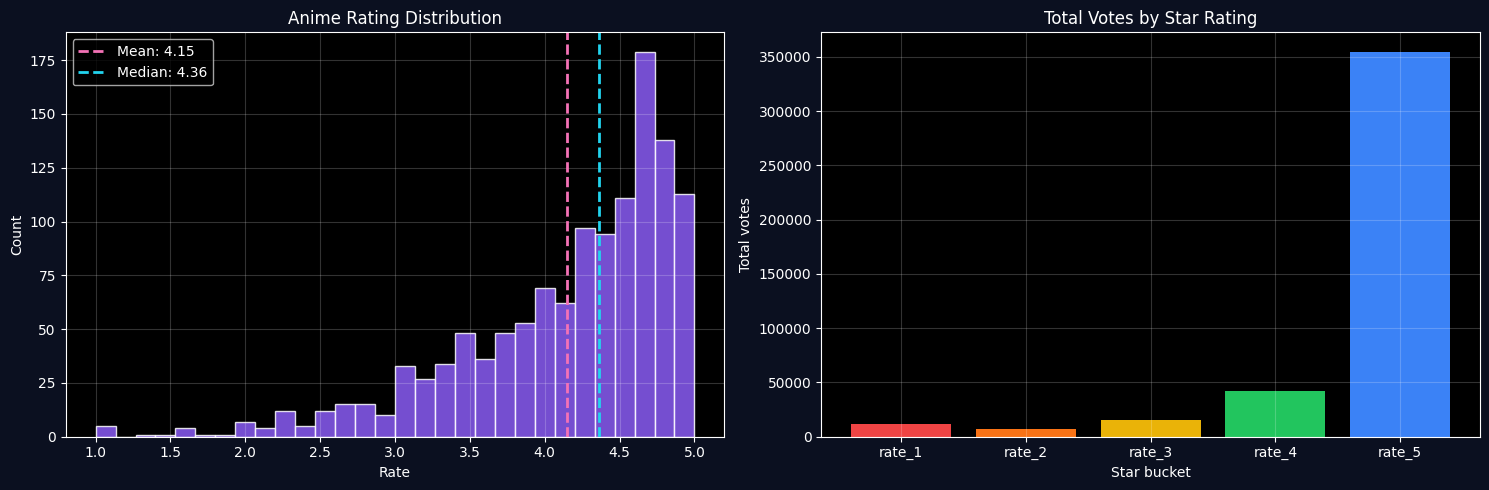

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('#0b1020')

rate_df = df[df['rate'].notna() & (df['rate'] > 0)]
ax[0].hist(rate_df['rate'], bins=30, color='#8b5cf6', edgecolor='white', alpha=0.85)
ax[0].axvline(rate_df['rate'].mean(), color='#f472b6', linestyle='--', linewidth=2, label=f"Mean: {rate_df['rate'].mean():.2f}")
ax[0].axvline(rate_df['rate'].median(), color='#22d3ee', linestyle='--', linewidth=2, label=f"Median: {rate_df['rate'].median():.2f}")
ax[0].set_title('Anime Rating Distribution')
ax[0].set_xlabel('Rate')
ax[0].set_ylabel('Count')
ax[0].legend()

star_cols = ['rate_1','rate_2','rate_3','rate_4','rate_5']
star_totals = df[star_cols].fillna(0).sum()
ax[1].bar(star_totals.index, star_totals.values, color=['#ef4444','#f97316','#eab308','#22c55e','#3b82f6'])
ax[1].set_title('Total Votes by Star Rating')
ax[1].set_xlabel('Star bucket')
ax[1].set_ylabel('Total votes')
for tick in ax:
    tick.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 4. Genre frequency

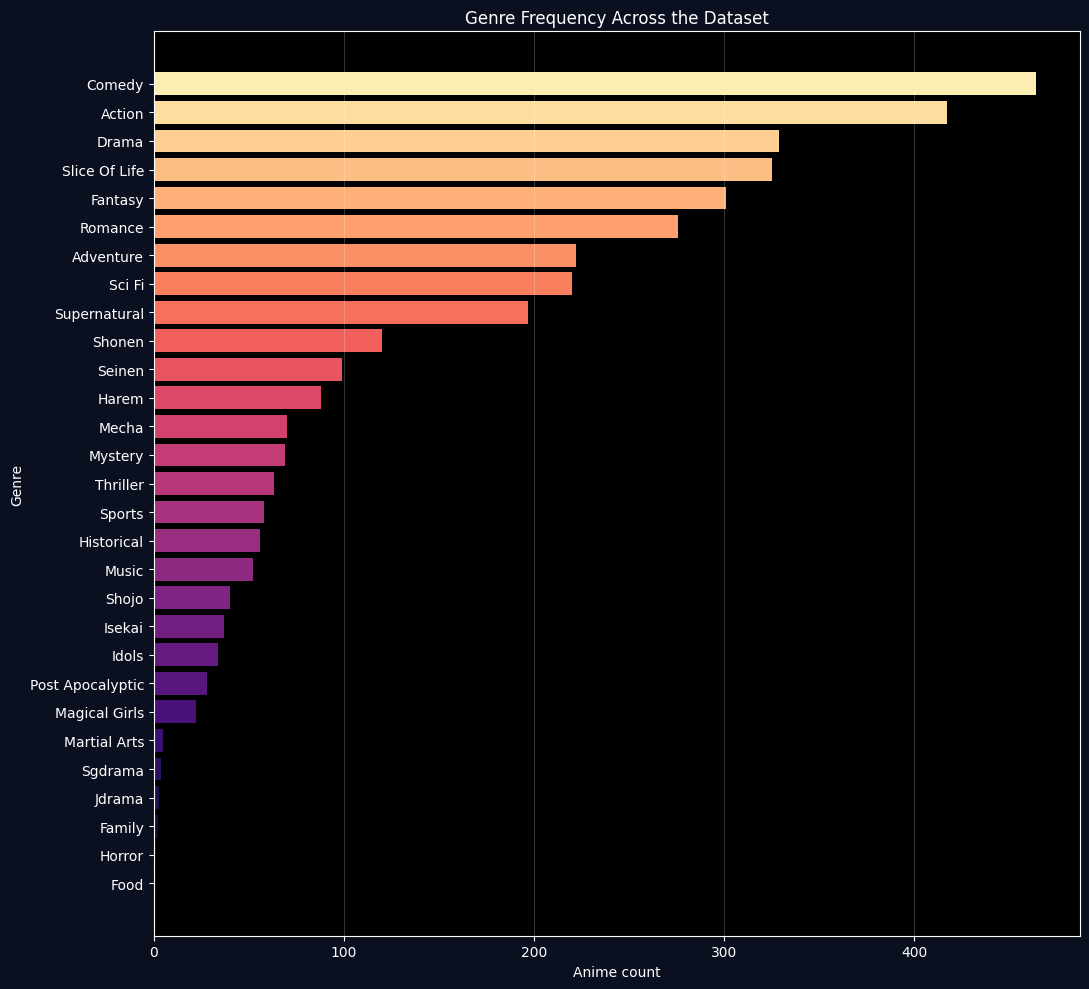

In [37]:
genre_counts = df[GENRE_COLS].fillna(0).sum().sort_values(ascending=True)
genre_counts.index = [g.replace('genre_','').replace('-', ' ').title() for g in genre_counts.index]

fig, ax = plt.subplots(figsize=(11, 10))
fig.patch.set_facecolor('#0b1020')
ax.barh(genre_counts.index, genre_counts.values, color=sns.color_palette('magma', len(genre_counts)))
ax.set_title('Genre Frequency Across the Dataset')
ax.set_xlabel('Anime count')
ax.set_ylabel('Genre')
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

## 5. Votes versus rating

In [38]:
scatter_df = df[df['votes'].fillna(0) > 0].copy()
fig = px.scatter(
    scatter_df,
    x='votes', y='rate',
    hover_name='anime',
    size='votes',
    color='rate',
    log_x=True,
    title='Votes vs Rating',
    color_continuous_scale='Plasma',
    template='plotly_dark'
)
fig.update_layout(paper_bgcolor='#0b1020', plot_bgcolor='#111827')
fig.show()

## 6. Genre co-occurrence

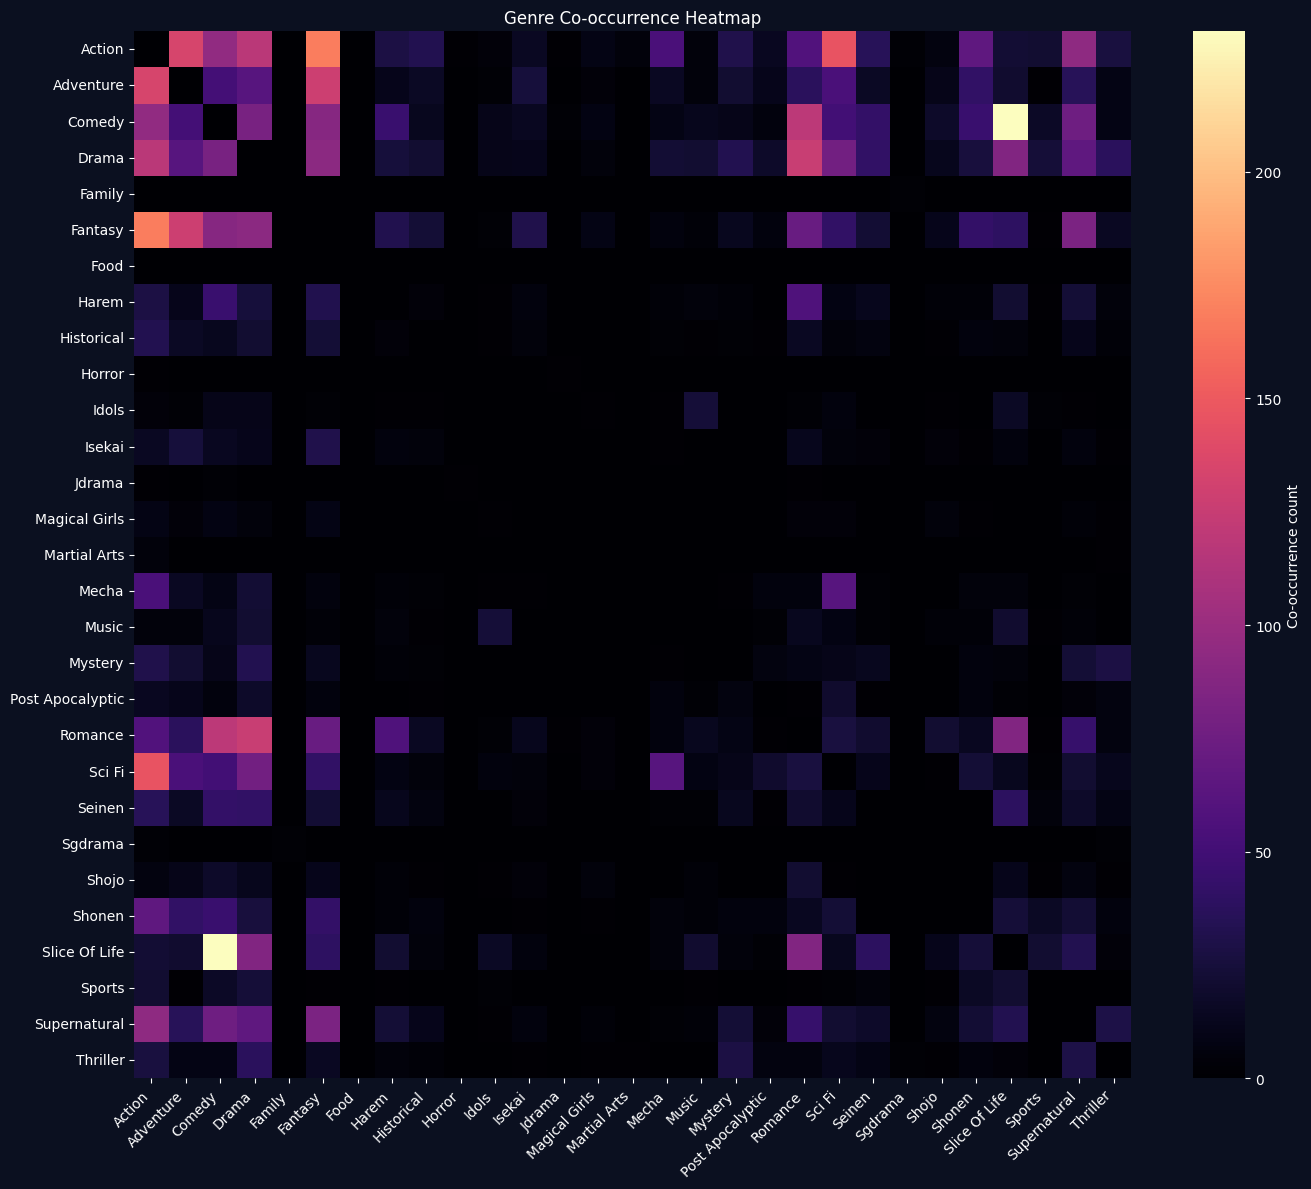

In [39]:
co_matrix = df[GENRE_COLS].fillna(0).T.dot(df[GENRE_COLS].fillna(0))
co_matrix.index = GENRE_LABELS
co_matrix.columns = GENRE_LABELS
np.fill_diagonal(co_matrix.values, 0)

fig, ax = plt.subplots(figsize=(14, 12))
fig.patch.set_facecolor('#0b1020')
sns.heatmap(co_matrix, cmap='magma', ax=ax, cbar_kws={'label': 'Co-occurrence count'})
ax.set_title('Genre Co-occurrence Heatmap')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Build recommendation features

In [40]:
model_df = df[df['votes'].fillna(0) >= 50].copy().reset_index(drop=True)
model_df[GENRE_COLS] = model_df[GENRE_COLS].fillna(0)
model_df['rate'] = pd.to_numeric(model_df['rate'], errors='coerce').fillna(0)

print('Model pool size:', len(model_df))

def build_feature_matrix(dataframe, genre_cols, genre_weight=0.7):
    genre_matrix = dataframe[genre_cols].astype(float).values * genre_weight
    rating_vector = (dataframe['rate'].values / 5.0).reshape(-1, 1) * (1 - genre_weight)
    return np.hstack([genre_matrix, rating_vector])

feature_matrix = build_feature_matrix(model_df, GENRE_COLS, genre_weight=0.7)
print('Feature matrix shape:', feature_matrix.shape)

Model pool size: 566
Feature matrix shape: (566, 30)


## 8. Weighted cosine similarity

In [41]:
similarity_matrix = cosine_similarity(feature_matrix)
np.fill_diagonal(similarity_matrix, 0)
print('Similarity matrix shape:', similarity_matrix.shape)

Similarity matrix shape: (566, 566)


## 9. Recommendation functions

In [42]:
def recommend_by_title(anime_name, top_n=10, genre_weight=0.7):
    local_matrix = build_feature_matrix(model_df, GENRE_COLS, genre_weight=genre_weight)
    idxs = model_df.index[model_df['anime'] == anime_name].tolist()
    if not idxs:
        return pd.DataFrame()
    idx = idxs[0]
    sims = cosine_similarity([local_matrix[idx]], local_matrix)[0]
    pairs = sorted(enumerate(sims), key=lambda x: x[1], reverse=True)
    pairs = [(i, s) for i, s in pairs if i != idx][:top_n]
    recs = model_df.iloc[[i for i, _ in pairs]][['anime','rate','votes','episodes','anime_url']].copy()
    recs['similarity_%'] = [round(s * 100, 2) for _, s in pairs]
    return recs.reset_index(drop=True)


def recommend_by_genres(selected_genres, top_n=10, genre_weight=0.7):
    if not selected_genres:
        return pd.DataFrame()
    local_matrix = build_feature_matrix(model_df, GENRE_COLS, genre_weight=genre_weight)
    query = np.zeros(len(GENRE_COLS) + 1)
    for i, col in enumerate(GENRE_COLS):
        label = col.replace('genre_', '').replace('-', ' ').title()
        if label in selected_genres:
            query[i] = genre_weight
    query[-1] = 1 - genre_weight
    sims = cosine_similarity([query], local_matrix)[0]
    pairs = sorted(enumerate(sims), key=lambda x: x[1], reverse=True)[:top_n]
    recs = model_df.iloc[[i for i, _ in pairs]][['anime','rate','votes','episodes','anime_url']].copy()
    recs['similarity_%'] = [round(s * 100, 2) for _, s in pairs]
    return recs.reset_index(drop=True)

## 10. Example recommendations

In [43]:
display(recommend_by_title('Naruto Shippuuden', top_n=10, genre_weight=0.7))
display(recommend_by_genres(['Action', 'Fantasy', 'Shonen'], top_n=10, genre_weight=0.7))

,anime,rate,votes,episodes,anime_url,similarity_%
0,Shugo Chara,4.86,33688,51,https://www.crunchyroll.com/shugo-chara,100.0
1,BLEACH,4.83,23900,366,https://www.crunchyroll.com/bleach,100.0
2,Naruto,4.80,16613,220,https://www.crunchyroll.com/naruto,100.0
3,REBORN!,4.88,12542,0,https://www.crunchyroll.com/reborn,100.0
4,Gintama,4.87,11435,379,https://www.crunchyroll.com/gintama,100.0
5,Hayate the Combat Butler! (S1 e S2),4.85,5689,77,https://www.crunchyroll.com/hayate-the-combat-...,100.0
6,Blue Exorcist,4.82,4498,12,https://www.crunchyroll.com/blue-exorcist,100.0
7,Durarara!!,4.85,4042,62,https://www.crunchyroll.com/durarara,100.0
8,Time of Eve,4.87,3864,6,https://www.crunchyroll.com/time-of-eve,100.0
9,Linebarrels of Iron,4.58,3026,0,https://www.crunchyroll.com/linebarrels-of-iron,100.0


,anime,rate,votes,episodes,anime_url,similarity_%
0,My Hero Academia,4.80,1025,86,https://www.crunchyroll.com/my-hero-academia,100.00
1,One Piece,4.70,1142,1135,https://www.crunchyroll.com/one-piece,87.15
2,Magi,4.69,298,25,https://www.crunchyroll.com/magi,87.15
3,Senyu.,4.35,78,26,https://www.crunchyroll.com/senyu,87.05
4,Dragon Ball Super,4.24,479,131,https://www.crunchyroll.com/dragon-ball-super,87.01
5,Os Cavaleiros do Zodíaco - Saintia Sho,3.78,82,10,https://www.crunchyroll.com/saint-seiya-sainti...,86.83
6,RADIANT,3.77,162,42,https://www.crunchyroll.com/radiant,86.82
7,JUNI TAISEN: ZODIAC WAR,3.29,208,12,https://www.crunchyroll.com/juni-taisenzodiac-war,86.60
8,BORUTO: NARUTO NEXT GENERATIONS,3.21,893,148,https://www.crunchyroll.com/boruto-naruto-next...,86.56
9,Ixion Saga DT,3.77,103,25,https://www.crunchyroll.com/ixion-saga-dt,82.62


## 11. Sensitivity check

In [44]:
for w in [1.0, 0.8, 0.7, 0.6]:
    print(f'Genre weight = {w}')
    display(recommend_by_title('Sword Art Online', top_n=5, genre_weight=w)[['anime','rate','similarity_%']])

Genre weight = 1.0


,anime,rate,similarity_%
0,07 Ghost,4.78,100.00
1,Comet Lucifer,2.87,100.00
2,Fairy Musketeers,4.77,70.71
3,Hiiro no Kakera,4.19,70.71
4,Yonna in the Solitary Fortress,3.83,70.71


Genre weight = 0.8


,anime,rate,similarity_%
0,07 Ghost,4.78,99.98
1,Comet Lucifer,2.87,99.73
2,Fairy Musketeers,4.77,71.67
3,Hiiro no Kakera,4.19,71.46
4,"If It's for My Daughter, I'd Even Defeat a Dem...",4.03,71.40


Genre weight = 0.7


,anime,rate,similarity_%
0,07 Ghost,4.78,99.96
1,Comet Lucifer,2.87,99.29
2,Fairy Musketeers,4.77,73.36
3,Hiiro no Kakera,4.19,72.81
4,"If It's for My Daughter, I'd Even Defeat a Dem...",4.03,72.65


Genre weight = 0.6


,anime,rate,similarity_%
0,07 Ghost,4.78,99.93
1,Comet Lucifer,2.87,98.64
2,Fairy Musketeers,4.77,76.38
3,Hiiro no Kakera,4.19,75.32
4,"If It's for My Daughter, I'd Even Defeat a Dem...",4.03,74.99


## 12. Summary Table

In [45]:
summary = pd.DataFrame({
    'metric': ['rows', 'filtered_rows_votes_ge_50', 'genres', 'avg_rate_filtered'],
    'value': [len(df), len(model_df), len(GENRE_COLS), round(model_df['rate'].mean(), 3)]
})
display(summary)

,metric,value
0,rows,1255.000
1,filtered_rows_votes_ge_50,566.000
2,genres,29.000
3,avg_rate_filtered,4.305
